### 글로벌 영화 블록버스터 예측
##### 이진 분류(Binary Classification)
- 1950~2026년까지의 글로벌 영화 데이터(100,000건)를 활용한다.
- 영화의 예산, 평점, 장르 등의 정보를 바탕으로 해당 영화가 블록버스터인지 예측하는 모델을 구축한다.

##### feature
- decade: 개봉 연대 (1950, 1960, ...)
- runtime_min: 상영 시간(분)
- genre: 장르 (Action|Drama 등, 파이프로 구분된 다중 장르)
- subgenre: 세부 장르
- country: 제작 국가
- imdb_rating: IMDb 평점
- budget_million: 제작 예산(백만 달러)
- marketing_budget_million: 마케팅 예산(백만 달러)
- popularity_score: 인기 점수
- metascore: 메타크리틱 점수
- audience_score: 관객 점수

##### target
- blockbuster_flag: 블록버스터 여부 (0: 아님, 1: 블록버스터)

##### 제외 컬럼
- movie_id, title: 단순 식별자
- revenue_million, roi_pct: 결과값 (data leakage)
- top_100_prob: 블록버스터와 직접 연관된 파생 지표
- franchise_flag: 다른 분류 대상
- director, lead_actor, lead_actress: 카테고리가 너무 많아 트리에 부적합
- release_year: decade와 중복
- language, streaming_platform: 예측에 불필요
- votes, award_nominations, award_wins: 결과 발생 후 집계되는 사후 지표

In [1]:
import pandas as pd

movie_df = pd.read_csv("./datasets/global_movies_dataset_1950_2026.csv")
movie_df

,movie_id,title,release_year,decade,runtime_min,genre,subgenre,director,lead_actor,lead_actress,...,roi_pct,popularity_score,metascore,audience_score,streaming_platform,award_nominations,award_wins,top_100_prob,blockbuster_flag,franchise_flag
0,1,Crimson Code,2001,2000,116,Action|Drama|Sci-Fi,Superhero,Denis Villeneuve,Brad Pitt,Tom Hanks,...,98.0,82.54,60,74,Netflix,3,2,0.560,0,0
1,2,Lost Empire,1951,1950,85,Crime|Animation,Gangster,Christopher Nolan,Scarlett Johansson,Brad Pitt,...,139.3,80.54,64,56,MGM+,0,0,0.549,0,0
2,3,Last Legacy,1990,1990,141,Sci-Fi|Drama,Cyberpunk,Bong Joon-ho,Emma Stone,Brad Pitt,...,-45.5,81.98,59,60,Peacock,1,1,0.520,0,0
3,4,Crimson River,1952,1950,82,Mystery|Romance,Whodunit,Quentin Tarantino,Meryl Streep,Tom Hanks,...,57.4,72.10,69,77,Disney+,1,1,0.498,0,0
4,5,Lost Dream,2011,2010,130,Romance,Romantic Drama,Quentin Tarantino,Robert Downey Jr.,Timothee Chalamet,...,97.8,60.63,48,57,Prime Video,0,0,0.435,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,Falling Code,1999,1990,118,Documentary|Mystery|Sci-Fi,Sports,Denis Villeneuve,Emma Stone,Christian Bale,...,509.6,85.19,51,69,Paramount+,0,0,0.529,0,0
99996,99997,Dark Secret,2007,2000,71,Mystery|Thriller,Supernatural Mystery,Steven Spielberg,Jennifer Lawrence,Meryl Streep,...,271.3,83.26,87,60,Hulu,0,0,0.586,0,0
99997,99998,Golden Storm,1951,1950,72,Action|Horror,Superhero,Steven Spielberg,Meryl Streep,Emma Stone,...,412.6,69.97,60,63,Apple TV+,3,2,0.553,1,0
99998,99999,Eternal River,1979,1970,131,Thriller|Animation,Survival,Patty Jenkins,Emma Stone,Emma Stone,...,-69.9,85.94,71,73,Apple TV+,1,0,0.560,0,0


In [2]:
movie_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   movie_id                  100000 non-null  int64  
 1   title                     100000 non-null  object 
 2   release_year              100000 non-null  int64  
 3   decade                    100000 non-null  int64  
 4   runtime_min               100000 non-null  int64  
 5   genre                     100000 non-null  object 
 6   subgenre                  100000 non-null  object 
 7   director                  100000 non-null  object 
 8   lead_actor                100000 non-null  object 
 9   lead_actress              100000 non-null  object 
 10  country                   100000 non-null  object 
 11  language                  100000 non-null  object 
 12  imdb_rating               100000 non-null  float64
 13  votes                     100000 non-null  in

In [3]:
movie_df.duplicated().sum()

np.int64(0)

In [4]:
movie_df.isna().sum()

movie_id                    0
title                       0
release_year                0
decade                      0
runtime_min                 0
genre                       0
subgenre                    0
director                    0
lead_actor                  0
lead_actress                0
country                     0
language                    0
imdb_rating                 0
votes                       0
budget_million              0
marketing_budget_million    0
revenue_million             0
roi_pct                     0
popularity_score            0
metascore                   0
audience_score              0
streaming_platform          0
award_nominations           0
award_wins                  0
top_100_prob                0
blockbuster_flag            0
franchise_flag              0
dtype: int64

In [5]:
movie_df.describe().T

,count,mean,std,min,25%,50%,75%,max
movie_id,100000.0,50000.500000,28867.657797,1.000,25000.750,50000.500,75000.2500,100000.00
release_year,100000.0,1988.013390,22.217453,1950.000,1969.000,1988.000,2007.0000,2026.00
decade,100000.0,1983.640400,22.274525,1950.000,1960.000,1980.000,2000.0000,2020.00
runtime_min,100000.0,113.712660,20.218836,70.000,100.000,114.000,127.0000,205.00
imdb_rating,100000.0,6.736212,1.014200,2.200,6.100,6.700,7.4000,9.80
votes,100000.0,40204.260940,52127.491206,425.000,12440.000,24305.000,47767.2500,1539859.00
budget_million,100000.0,48.269718,43.584906,0.500,16.070,34.860,68.0000,284.42
marketing_budget_million,100000.0,22.966829,24.086906,0.100,6.320,14.960,31.0100,180.00
revenue_million,100000.0,133.313829,196.396971,0.060,24.420,66.145,159.5625,2940.58
roi_pct,100000.0,176.872003,238.856193,-90.000,14.800,100.900,253.9250,1100.60


#### 불필요한 컬럼 제거
- 식별자(movie_id, title), 결과 지표(revenue, roi, top_100_prob), 사후 지표(votes, awards) 등을 제거한다.
- 카테고리가 지나치게 많은 컬럼(director, lead_actor, lead_actress)도 제거한다.

In [6]:
drop_cols = ['movie_id', 'title', 'revenue_million', 'roi_pct',
             'top_100_prob', 'franchise_flag',
             'director', 'lead_actor', 'lead_actress',
             'release_year', 'language', 'streaming_platform',
             'votes', 'award_nominations', 'award_wins']

movie_df = movie_df.drop(columns=drop_cols)
movie_df

,decade,runtime_min,genre,subgenre,country,imdb_rating,budget_million,marketing_budget_million,popularity_score,metascore,audience_score,blockbuster_flag
0,2000,116,Action|Drama|Sci-Fi,Superhero,UK,7.0,56.07,25.42,82.54,60,74,0
1,1950,85,Crime|Animation,Gangster,France,6.8,45.29,31.19,80.54,64,56,0
2,1990,141,Sci-Fi|Drama,Cyberpunk,Japan,6.2,60.71,21.94,81.98,59,60,0
3,1950,82,Mystery|Romance,Whodunit,France,6.3,37.16,26.62,72.10,69,77,0
4,2010,130,Romance,Romantic Drama,Germany,5.6,19.78,6.23,60.63,48,57,0
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1990,118,Documentary|Mystery|Sci-Fi,Sports,Japan,6.1,5.45,4.33,85.19,51,69,0
99996,2000,71,Mystery|Thriller,Supernatural Mystery,France,6.6,23.05,11.81,83.26,87,60,0
99997,1950,72,Action|Horror,Superhero,Canada,7.4,90.77,69.78,69.97,60,63,1
99998,1970,131,Thriller|Animation,Survival,Germany,6.4,41.72,12.20,85.94,71,73,0


#### 이상치 제거 (IQR)
- 수치형 컬럼 중 분포가 비대칭인 budget_million, marketing_budget_million에 대해 IQR 방식으로 이상치를 제거한다.
- IQR = Q3 - Q1, 허용 범위: Q1 - 1.5 * IQR ~ Q3 + 1.5 * IQR

<Axes: >

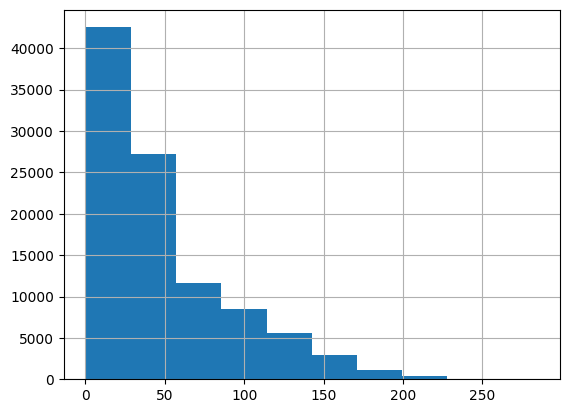

In [7]:
movie_df.budget_million.hist()

In [8]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    iqr = Q3 - Q1
    lower_bound = Q1 - 1.5 * iqr
    upper_bound = Q3 + 1.5 * iqr
    if lower_bound < 0:
        lower_bound = 0
    print(f'{column}: {lower_bound} ~ {upper_bound}')
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

movie_df = remove_outliers_iqr(movie_df, 'budget_million')
movie_df = remove_outliers_iqr(movie_df, 'marketing_budget_million')
movie_df = movie_df.reset_index(drop=True)
print(f'\n이상치 제거 후 데이터 수: {len(movie_df)}')

budget_million: 0 ~ 145.89499999999998
marketing_budget_million: 0 ~ 61.53

이상치 제거 후 데이터 수: 90395


#### 인코딩
- genre: 파이프(|)로 다중 장르가 묶여 있으므로 MultiLabelBinarizer를 사용하여 장르별 원핫 인코딩
- subgenre: 단일 카테고리이므로 LabelEncoder 사용 (트리 모델은 서열 오해 없음)
- country: 단일 카테고리이므로 LabelEncoder 사용

In [9]:
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer

movie_enc_df = movie_df.copy()

# 1. genre → MultiLabelBinarizer (다중 장르를 각각 원핫 인코딩)
mlb = MultiLabelBinarizer()
genre_split = movie_enc_df['genre'].str.split('|')
genre_onehot = mlb.fit_transform(genre_split)
genre_onehot_df = pd.DataFrame(data=genre_onehot, columns=mlb.classes_)

# genre 컬럼 제거 후 원핫 컬럼 붙이기
movie_enc_df = movie_enc_df.drop(columns=['genre'])
movie_enc_df = pd.concat([movie_enc_df, genre_onehot_df], axis=1)

# 2. subgenre → LabelEncoder
subgenre_encoder = LabelEncoder()
movie_enc_df['subgenre'] = subgenre_encoder.fit_transform(movie_enc_df['subgenre'])

# 3. country → LabelEncoder
country_encoder = LabelEncoder()
movie_enc_df['country'] = country_encoder.fit_transform(movie_enc_df['country'])

movie_enc_df

,decade,runtime_min,subgenre,country,imdb_rating,budget_million,marketing_budget_million,popularity_score,metascore,audience_score,...,Comedy,Crime,Documentary,Drama,Fantasy,Horror,Mystery,Romance,Sci-Fi,Thriller
0,2000,116,41,8,7.0,56.07,25.42,82.54,60,74,...,0,0,0,1,0,0,0,0,1,0
1,1950,85,17,2,6.8,45.29,31.19,80.54,64,56,...,0,1,0,0,0,0,0,0,0,0
2,1990,141,5,6,6.2,60.71,21.94,81.98,59,60,...,0,0,0,1,0,0,0,0,1,0
3,1950,82,50,2,6.3,37.16,26.62,72.10,69,77,...,0,0,0,0,0,0,1,1,0,0
4,2010,130,33,3,5.6,19.78,6.23,60.63,48,57,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90390,1990,117,7,6,4.8,50.69,28.45,63.71,58,49,...,0,0,0,0,1,0,0,0,0,1
90391,1990,118,39,6,6.1,5.45,4.33,85.19,51,69,...,0,0,1,0,0,0,1,0,1,0
90392,2000,71,43,2,6.6,23.05,11.81,83.26,87,60,...,0,0,0,0,0,0,1,0,0,1
90393,1970,131,44,3,6.4,41.72,12.20,85.94,71,73,...,0,0,0,0,0,0,0,0,0,1


In [10]:
print(f'genre classes: {mlb.classes_}')
print(f'subgenre classes: {subgenre_encoder.classes_}')
print(f'country classes: {country_encoder.classes_}')

genre classes: ['Action' 'Adventure' 'Animation' 'Comedy' 'Crime' 'Documentary' 'Drama'
 'Fantasy' 'Horror' 'Mystery' 'Romance' 'Sci-Fi' 'Thriller']
subgenre classes: ['Adventure Animation' 'Biography' 'Comedy Animation' 'Conspiracy'
 'Crime Thriller' 'Cyberpunk' 'Dark Comedy' 'Dark Fantasy' 'Detective'
 'Detective Mystery' 'Dystopian' 'Epic Fantasy' 'Epic Quest' 'Family'
 'Family Animation' 'Fantasy Animation' 'Found Footage' 'Gangster'
 'Gothic' 'Heist' 'Historical' 'Jungle' 'Martial Arts' 'Military'
 'Murder Mystery' 'Mythic' 'Nature' 'Noir' 'Period Romance' 'Political'
 'Politics' 'Psychological' 'Rom-Com' 'Romantic Drama' 'Satire'
 'Slapstick' 'Slasher' 'Social' 'Space Opera' 'Sports' 'Spy' 'Superhero'
 'Supernatural' 'Supernatural Mystery' 'Survival' 'Teen Romance'
 'Time Travel' 'Tragic Romance' 'Treasure Hunt' 'Urban Fantasy' 'Whodunit']
country classes: ['Australia' 'Canada' 'France' 'Germany' 'India' 'Italy' 'Japan'
 'South Korea' 'UK' 'USA']


In [11]:
movie_enc_df.blockbuster_flag.value_counts()

blockbuster_flag
0    74184
1    16211
Name: count, dtype: int64

#### Decision Tree 학습

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import export_graphviz
import graphviz

dtc = DecisionTreeClassifier()

feature, target = movie_enc_df.drop(columns=['blockbuster_flag']), movie_enc_df['blockbuster_flag']

X_train, X_test, y_train, y_test = \
train_test_split(feature, target, test_size=0.2, random_state=124)

dtc.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
export_graphviz(
    dtc,
    out_file='./images/movie_dtc01.dot',
    class_names=['Not Blockbuster', 'Blockbuster'],
    feature_names=feature.columns,
    impurity=True,
    filled=True,
    max_depth=3
)

In [14]:
with open('./images/movie_dtc01.dot') as f:
    movie_dtc01 = f.read()

movie_dtc01_graph = graphviz.Source(movie_dtc01)
movie_dtc01_graph.render(filename='movie_dtc01', directory='./images', format='png')

'images\\movie_dtc01.png'

<img src='./images/movie_dtc01.png'>

#### Feature Importance (특성 중요도)

In [15]:
print(feature.columns.tolist())
print(dtc.feature_importances_)

['decade', 'runtime_min', 'subgenre', 'country', 'imdb_rating', 'budget_million', 'marketing_budget_million', 'popularity_score', 'metascore', 'audience_score', 'Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Horror', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller']
[0.03199186 0.06986955 0.05312729 0.03844346 0.0560583  0.30623828
 0.08139561 0.15903983 0.06234709 0.06349467 0.00656248 0.00586743
 0.00591594 0.00534409 0.00735708 0.00616692 0.00638401 0.00533972
 0.00462052 0.00645852 0.00580305 0.00612435 0.00604994]


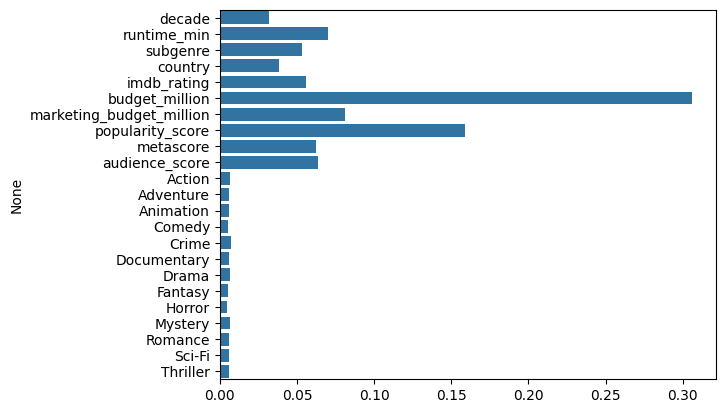

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x=dtc.feature_importances_, y=feature.columns)
plt.show()

#### Decision Boundary 시각화
- feature importance가 가장 높은 2개의 feature를 선택하여 Decision Boundary를 시각화한다.

In [17]:
import numpy as np

def visualize_boundary(model, X, y):
    fig, ax = plt.subplots()
    
    ax.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, s=25, cmap='rainbow', edgecolor='k',
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim_start, xlim_end = ax.get_xlim()
    ylim_start, ylim_end = ax.get_ylim()
    
    model.fit(X.values, y)
    xx, yy = np.meshgrid(np.linspace(xlim_start, xlim_end, num=200),
                         np.linspace(ylim_start, ylim_end, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap='rainbow',
                           zorder=1)

상위 2개 feature: ['budget_million', 'popularity_score']


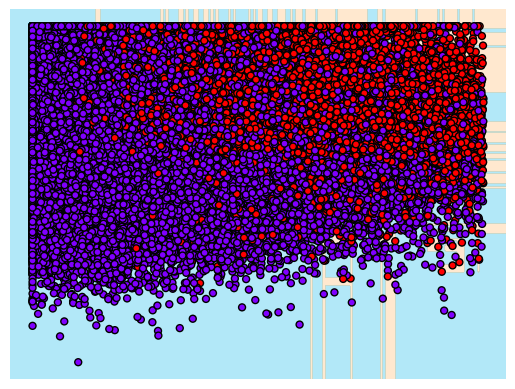

In [18]:
# feature importance 상위 2개 feature 추출
top2_idx = np.argsort(dtc.feature_importances_)[::-1][:2]
top2_features = feature.columns[top2_idx].tolist()
print(f'상위 2개 feature: {top2_features}')

visualize_boundary(dtc, feature[top2_features], target)

#### 정확도 평가

In [19]:
from sklearn.metrics import accuracy_score

# visualize_boundary에서 2개 feature로 재학습되었으므로 전체 feature로 다시 학습
dtc.fit(X_train, y_train)
prediction = dtc.predict(X_test)
print(f'전체 feature 정확도: {accuracy_score(y_test, prediction)}')

# 상위 2개 feature만으로 별도 모델 학습 후 정확도 측정
dtc_top2 = DecisionTreeClassifier()
dtc_top2.fit(X_train[top2_features], y_train)
prediction_top2 = dtc_top2.predict(X_test[top2_features])
print(f'상위 2개 feature 정확도: {accuracy_score(y_test, prediction_top2)}')

전체 feature 정확도: 0.7973339233364677
상위 2개 feature 정확도: 0.7949001604071022


#### 하이퍼파라미터 튜닝 (max_depth 제한)

In [20]:
dtc2 = DecisionTreeClassifier(max_depth=5)

X_train, X_test, y_train, y_test = \
train_test_split(feature, target, test_size=0.2, random_state=124)

dtc2.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


상위 2개 feature: ['budget_million', 'popularity_score']


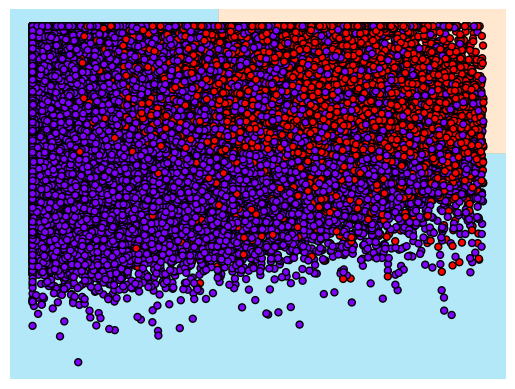

In [21]:
top2_idx2 = np.argsort(dtc2.feature_importances_)[::-1][:2]
top2_features2 = feature.columns[top2_idx2].tolist()
print(f'상위 2개 feature: {top2_features2}')

visualize_boundary(dtc2, feature[top2_features2], target)

In [22]:
# visualize_boundary에서 2개 feature로 재학습되었으므로 전체 feature로 다시 학습
dtc2.fit(X_train, y_train)
prediction2 = dtc2.predict(X_test)
print(f'max_depth=5, 전체 feature 정확도: {accuracy_score(y_test, prediction2)}')

# 상위 2개 feature만으로 별도 모델 학습 후 정확도 측정
dtc2_top2 = DecisionTreeClassifier(max_depth=5)
dtc2_top2.fit(X_train[top2_features2], y_train)
prediction2_top2 = dtc2_top2.predict(X_test[top2_features2])
print(f'max_depth=5, 상위 2개 feature 정확도: {accuracy_score(y_test, prediction2_top2)}')

max_depth=5, 전체 feature 정확도: 0.8522042148348913
max_depth=5, 상위 2개 feature 정확도: 0.8515404613087008
